In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import re
import os
os.environ['TF_CPP_MIN_LOG_LEVEL']='2'
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Embedding,Dense,Dropout,Flatten
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,accuracy_score,classification_report

In [100]:
df=pd.read_csv("/content/complaints_processed.csv")
df

,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...
...,...,...,...
76892,76892,credit_reporting,sent dispute removed due seven year limitation...
76893,76893,debt_collection,sent first letter portfolio recovery associate...
76894,76894,mortgages_and_loans,sent following letter caliber without reply pr...
76895,76895,credit_reporting,sent following letter experian credit score in...


In [101]:
df.drop(columns='Unnamed: 0',axis=1,inplace=True)

In [102]:
df.tail(10)

,product,narrative
76887,debt_collection,sent credit bureau profession credit dispute c...
76888,credit_reporting,sent dispute credit agency changed others jpmo...
76889,credit_reporting,sent dispute credit agency changed others priv...
76890,credit_reporting,sent dispute credit agency changed others priv...
76891,credit_reporting,sent dispute removed due seven year limitation...
76892,credit_reporting,sent dispute removed due seven year limitation...
76893,debt_collection,sent first letter portfolio recovery associate...
76894,mortgages_and_loans,sent following letter caliber without reply pr...
76895,credit_reporting,sent following letter experian credit score in...
76896,credit_reporting,sent following letter credit score investigati...


In [103]:
df=df[df['narrative']!='name']
df

,product,narrative
0,credit_card,purchase order day shipping amount receive pro...
1,credit_card,forwarded message date tue subject please inve...
2,retail_banking,forwarded message cc sent friday pdt subject f...
3,credit_reporting,payment history missing credit report speciali...
4,credit_reporting,payment history missing credit report made mis...
...,...,...
76892,credit_reporting,sent dispute removed due seven year limitation...
76893,debt_collection,sent first letter portfolio recovery associate...
76894,mortgages_and_loans,sent following letter caliber without reply pr...
76895,credit_reporting,sent following letter experian credit score in...


In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76897 entries, 0 to 76896
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   product    76897 non-null  object
 1   narrative  76893 non-null  object
dtypes: object(2)
memory usage: 1.2+ MB


In [105]:
df.describe(include='O')

,product,narrative
count,76897,76893
unique,5,56675
top,credit_reporting,victim identity notified collection creditor s...
freq,44652,739


In [106]:
df.duplicated().sum()

np.int64(20112)

In [107]:
df.drop_duplicates(inplace=True)

In [108]:
df.isna().sum()

,0
product,0
narrative,1


In [109]:
df.dropna(subset=['narrative'],inplace=True)

In [110]:
df.reset_index(drop=True,inplace=True)

In [111]:
df['product'].unique()

array(['credit_card', 'retail_banking', 'credit_reporting',
       'mortgages_and_loans', 'debt_collection'], dtype=object)

In [112]:
df1=df['product'].value_counts()
df1

,count
product,
credit_reporting,26071
debt_collection,9482
mortgages_and_loans,8174
credit_card,7404
retail_banking,5653


Text(0.5, 1.0, 'Product Value Count')

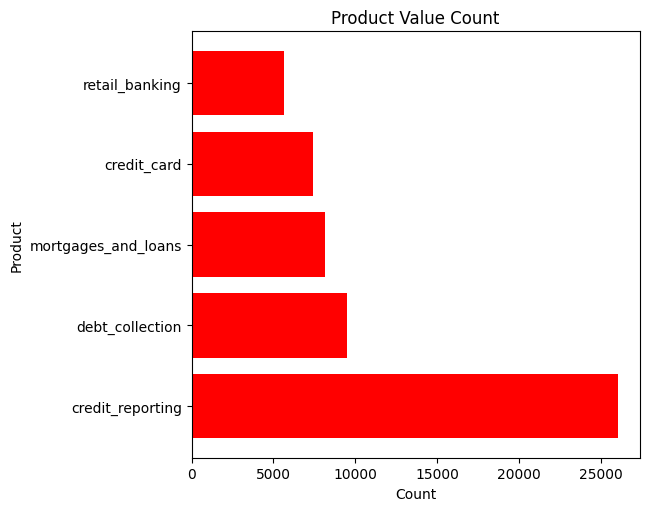

In [113]:
plt.barh(df1.index,df1.values,color='r')
plt.tight_layout()
plt.xlabel('Count')
plt.ylabel('Product')
plt.title('Product Value Count')

In [114]:
encoder=LabelEncoder()
df['product']=encoder.fit_transform(df['product'])

In [115]:
def clean_text(text):
    text=text.lower()
    text=re.sub(r'\n',' ',text)
    text=re.sub(r'\s+',' ',text)
    return text

df['narrative']=df['narrative'].apply(clean_text)

In [116]:
df

,product,narrative
0,0,purchase order day shipping amount receive pro...
1,0,forwarded message date tue subject please inve...
2,4,forwarded message cc sent friday pdt subject f...
3,1,payment history missing credit report speciali...
4,1,payment history missing credit report made mis...
...,...,...
56779,1,sent dispute removed due seven year limitation...
56780,2,sent first letter portfolio recovery associate...
56781,3,sent following letter caliber without reply pr...
56782,1,sent following letter experian credit score in...


In [117]:
x=df['narrative']
y=df['product']

In [118]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)
x_train

,narrative
17126,partner bought four pair pant returned three p...
23212,currently working loan serviced fedloan servic...
39676,trying remove fraud alert three credit credit ...
55061,refinanced property texas current lienholder p...
27616,call kia finance end told could defer payment ...
...,...
22318,victim identity theft due corona virus pandemi...
19528,hello writing two new item added credit report...
5151,payed excellence mortgage year closed bank che...
51839,received big lump sum money bank america accou...


In [119]:
max_words=10000
max_len=200
tokenize=Tokenizer(num_words=max_words,oov_token='<OOV>')
tokenize.fit_on_texts(x_train)
x_train_seq=tokenize.texts_to_sequences(x_train)
x_test_seq=tokenize.texts_to_sequences(x_test)
x_train_pad=pad_sequences(x_train_seq,maxlen=max_len,padding='post')
x_test_pad=pad_sequences(x_test_seq,maxlen=max_len,padding='post')

In [120]:
from tensorflow.keras.layers import LSTM, Bidirectional

num_classes = y_train.nunique()
ann = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

In [121]:
# num_classes = y_train.nunique()
# ann=Sequential([
#     Embedding(input_dim=max_words,output_dim=128,input_length=max_len),
#     Flatten(),
#     Dense(128,activation='relu'),
#     Dropout(0.5),
#     Dense(64,activation='relu'),
#     Dropout(0.5),
#     Dense(num_classes,activation='softmax')
# ])

In [122]:
ann.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [123]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [124]:
ann.fit(x_train_pad,y_train,batch_size=32,epochs=20,validation_split=0.2, callbacks=[early_stopping])

Epoch 1/20
1136/1136 ━━━━━━━━━━━━━━━━━━━━ 42s 34ms/step - accuracy: 0.7521 - loss: 0.7139 - val_accuracy: 0.8300 - val_loss: 0.5166
Epoch 2/20
1136/1136 ━━━━━━━━━━━━━━━━━━━━ 42s 37ms/step - accuracy: 0.8453 - loss: 0.4881 - val_accuracy: 0.8259 - val_loss: 0.4978
Epoch 3/20
1136/1136 ━━━━━━━━━━━━━━━━━━━━ 38s 33ms/step - accuracy: 0.8685 - loss: 0.4107 - val_accuracy: 0.8194 - val_loss: 0.5264
Epoch 4/20
1136/1136 ━━━━━━━━━━━━━━━━━━━━ 38s 34ms/step - accuracy: 0.8838 - loss: 0.3575 - val_accuracy: 0.8274 - val_loss: 0.5359
Epoch 5/20
1136/1136 ━━━━━━━━━━━━━━━━━━━━ 40s 35ms/step - accuracy: 0.8985 - loss: 0.3184 - val_accuracy: 0.8213 - val_loss: 0.5580
Epoch 6/20
1136/1136 ━━━━━━━━━━━━━━━━━━━━ 39s 34ms/step - accuracy: 0.9109 - loss: 0.2771 - val_accuracy: 0.8227 - val_loss: 0.5922
Epoch 7/20
1136/1136 ━━━━━━━━━━━━━━━━━━━━ 40s 35ms/step - accuracy: 0.9239 - loss: 0.2425 - val_accuracy: 0.8154 - val_loss: 0.6535


In [125]:
y_pred_prob=ann.predict(x_test_pad)
y_pred_prob

355/355 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step


array([[1.23641989e-03, 3.54194403e-01, 6.41901314e-01, 2.50177667e-03,
        1.66100654e-04],
       [1.90069305e-03, 8.73381257e-01, 1.22425064e-01, 2.13642186e-03,
        1.56451963e-04],
       [1.55046539e-04, 9.96978164e-01, 2.78985873e-03, 7.33452543e-05,
        3.52589768e-06],
       ...,
       [1.84035068e-03, 8.71928990e-01, 1.12275984e-02, 1.14798151e-01,
        2.04841854e-04],
       [3.82347940e-03, 9.01776850e-01, 9.13260356e-02, 2.57338327e-03,
        5.00285532e-04],
       [2.81989202e-03, 9.74314451e-01, 1.26628159e-02, 9.97656491e-03,
        2.26258926e-04]], dtype=float32)

In [126]:
y_pred=np.argmax(y_pred_prob,axis=1)
y_pred

array([2, 1, 1, ..., 1, 1, 1])

In [127]:
cm=confusion_matrix(y_test,y_pred)
cm

array([[1112,  228,   31,   32,   78],
       [  79, 4757,  262,   87,   29],
       [  68,  340, 1379,   82,   27],
       [  23,  274,   44, 1254,   40],
       [ 168,   24,   12,   26,  901]])

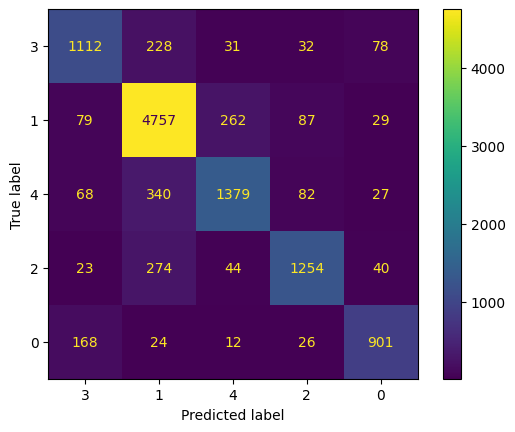

In [128]:
lab=[3,1,4,2,0]
cmd=ConfusionMatrixDisplay(cm,display_labels=lab)
cmd.plot()

In [129]:
score=accuracy_score(y_test,y_pred)*100
score

82.79475213524698

In [130]:
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.77      0.75      0.76      1481
           1       0.85      0.91      0.88      5214
           2       0.80      0.73      0.76      1896
           3       0.85      0.77      0.80      1635
           4       0.84      0.80      0.82      1131

    accuracy                           0.83     11357
   macro avg       0.82      0.79      0.80     11357
weighted avg       0.83      0.83      0.83     11357

